### Workshop the steps in a synthetic reconstruction of narG variants. 

First, build two faa's, one to be used as a reference, the other to generate raw reads.

In [1]:
import numpy as np
import tqdm


KO = 'K00370'
ref_directory = f'../data/whole_genomes/{KO}_rep.faa'

from Bio import SeqIO
import random

# Read all sequences
records = list(SeqIO.parse(ref_directory, "fasta"))
print(f"Total sequences: {len(records)}")


random.seed(42) #I'm fixing a seed here
random.shuffle(records) 

spikein_set = records[:100]

# Write outputs
SeqIO.write(spikein_set, f"../out/reconstruction/spikein_{KO}.faa", "fasta")

print(f"Spike-in: {len(spikein_set)} sequences")

Total sequences: 906
Spike-in: 100 sequences


Generate raw reads

In [254]:
from Bio import SeqIO
import random

def back_translate(protein_seq):
    """Convert protein sequence to DNA using common codons"""
    codon_table = {
        'A': 'GCT', 'R': 'CGT', 'N': 'AAT', 'D': 'GAT',
        'C': 'TGT', 'Q': 'CAG', 'E': 'GAA', 'G': 'GGT',
        'H': 'CAT', 'I': 'ATT', 'L': 'CTG', 'K': 'AAA',
        'M': 'ATG', 'F': 'TTT', 'P': 'CCT', 'S': 'TCT',
        'T': 'ACT', 'W': 'TGG', 'Y': 'TAT', 'V': 'GTT',
        '*': 'TAA'
    }
    dna_seq = ''
    for aa in protein_seq:
        dna_seq += codon_table.get(aa, 'NNN')  # Use NNN for unknown amino acids
    return dna_seq

def add_sequencing_errors(read, error_rate=0.001):
    """Add simple substitution errors to simulate sequencing errors"""
    bases = ['A', 'T', 'C', 'G']
    result = []
    for base in read:
        if random.random() < error_rate:
            # Choose a different base
            new_base = random.choice([b for b in bases if b != base])
            result.append(new_base)
        else:
            result.append(base)
    return ''.join(result)

def generate_paired_end_reads(dna_sequence, read_length=150, coverage=30, insert_size=300, error_rate=0.001):
    """Generate paired-end reads with proper insert size"""
    reads_r1 = []
    reads_r2 = []
    seq_length = len(dna_sequence)
    
    # Calculate number of read pairs needed
    num_pairs = int((seq_length * coverage) // (2 * read_length))
    
    for _ in range(num_pairs):
        # Random start position for R1
        start_r1 = random.randint(0, seq_length - insert_size)
        end_r1 = start_r1 + read_length
        start_r2 = start_r1 + insert_size - read_length
        
        # Ensure we don't go beyond sequence boundaries
        if start_r2 + read_length <= seq_length:
            read_r1 = dna_sequence[start_r1:end_r1]
            read_r2 = dna_sequence[start_r2:start_r2 + read_length]
            
            # Add seequencing errors
            read_r1 = add_sequencing_errors(read_r1, error_rate = error_rate)
            read_r2 = add_sequencing_errors(read_r2, error_rate = error_rate)
            
            # R2 is reverse complement (simulating actual sequencing)
            read_r2 = reverse_complement(read_r2)
            
            reads_r1.append(read_r1)
            reads_r2.append(read_r2)
    
    return reads_r1, reads_r2

def reverse_complement(seq):
    """Simple reverse complement"""
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G', 'N': 'N'}
    return ''.join(comp.get(base, base) for base in reversed(seq))

# Read spike-in protein sequences
spikein_records = list(SeqIO.parse(f"../out/reconstruction/spikein_{KO}.faa", "fasta"))


#Generate many raw reads in a loop
coverage_sweep = np.rint(np.logspace(0.6,2,20)).astype(int)
error_sweep = [0.001]
for cov in coverage_sweep:
    for err in error_sweep:
        # Generate paired-end DNA reads
        all_r1 = []
        all_r2 = []

        for record in spikein_records:
            # Convert protein to DNA first!
            dna_sequence = back_translate(str(record.seq))
            # print(f"Converted {record.id}: {len(record.seq)}aa -> {len(dna_sequence)}bp DNA")
            
            r1, r2 = generate_paired_end_reads(dna_sequence, read_length=150, coverage = cov, error_rate = err)
            all_r1.extend(r1)
            all_r2.extend(r2)

        print(f"Generated {len(all_r1)} DNA read pairs")

        # Write R1 and R2 files as FASTA
        with open(f"../out/reconstruction/raw_reads/{KO}/spikein_R1_{cov:.0f}_{err:.3f}.fasta", "w") as f1, \
            open(f"../out/reconstruction/raw_reads/{KO}/spikein_R2_{cov:.0f}_{err:.3f}.fasta", "w") as f2:
            
            for i, (read1, read2) in enumerate(zip(all_r1, all_r2)):
                # R1 file - FASTA format
                f1.write(f">read_{i}/1\n")
                f1.write(f"{read1}\n")
                
                # R2 file - FASTA format  
                f2.write(f">read_{i}/2\n")
                f2.write(f"{read2}\n")

        print("Paired-end DNA reads written to:")
        print(f"  ../out/reconstruction/raw_reads/{KO}/spikein_R1_{cov:.0f}_{err:.3f}.fasta")
        print(f"  ../out/reconstruction/raw_reads/{KO}/spikein_R2_{cov:.0f}_{err:.3f}.fasta")

Generated 4779 DNA read pairs
Paired-end DNA reads written to:
  ../out/reconstruction/raw_reads/K00370/spikein_R1_4_0.001.fasta
  ../out/reconstruction/raw_reads/K00370/spikein_R2_4_0.001.fasta
Generated 5996 DNA read pairs
Paired-end DNA reads written to:
  ../out/reconstruction/raw_reads/K00370/spikein_R1_5_0.001.fasta
  ../out/reconstruction/raw_reads/K00370/spikein_R2_5_0.001.fasta
Generated 7199 DNA read pairs
Paired-end DNA reads written to:
  ../out/reconstruction/raw_reads/K00370/spikein_R1_6_0.001.fasta
  ../out/reconstruction/raw_reads/K00370/spikein_R2_6_0.001.fasta
Generated 8407 DNA read pairs
Paired-end DNA reads written to:
  ../out/reconstruction/raw_reads/K00370/spikein_R1_7_0.001.fasta
  ../out/reconstruction/raw_reads/K00370/spikein_R2_7_0.001.fasta
Generated 9613 DNA read pairs
Paired-end DNA reads written to:
  ../out/reconstruction/raw_reads/K00370/spikein_R1_8_0.001.fasta
  ../out/reconstruction/raw_reads/K00370/spikein_R2_8_0.001.fasta
Generated 10821 DNA read 

In [253]:

coverage_sweep = np.rint(np.logspace(0.6, 2, 20))
print(coverage_sweep)

[  4.   5.   6.   7.   8.   9.  11.  13.  15.  18.  22.  26.  30.  36.
  43.  51.  60.  71.  84. 100.]


### Then we moved to QUEST to generate contigs and ORFs from these raw reads. 

Analysis of those results is below. 

In [2]:
from Bio import SeqIO
from Bio.Align import PairwiseAligner
import numpy as np
from collections import defaultdict


def assess_reconstruction(spikein_faa, prodigal_faa, identity_threshold=0.9, coverage_threshold=0.8, length_threshold = 0.3):
    """
    Assess how many spike-in variants were successfully reconstructed
    using local alignment with both identity and coverage thresholds.
    """
    # Load sequences
    spikein_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(spikein_faa, "fasta")}
    prodigal_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(prodigal_faa, "fasta")}
    
    # Calculate mean spike-in length for faux detection
    spikein_lengths = [len(seq) for seq in spikein_seqs.values()]
    mean_spikein_length = np.mean(spikein_lengths)
    
    print(f"=== Reconstruction Assessment ===")
    print(f"Spike-in variants: {len(spikein_seqs)}")
    print(f"Reconstructed ORFs: {len(prodigal_seqs)}")
    print(f"Mean spike-in length: {mean_spikein_length:.0f} aa")
    print(f"Thresholds: identity ≥ {identity_threshold}, coverage ≥ {coverage_threshold}")
    
    # Local alignment setup
    aligner = PairwiseAligner()
    aligner.mode = 'local'
    aligner.match_score = 1
    aligner.mismatch_score = 0
    aligner.open_gap_score = -1
    aligner.extend_gap_score = 0
    
    # OPTIMIZATION 1: Pre-filter full-length ORFs
    full_length_orfs = {}
    for orf_id, orf_seq in prodigal_seqs.items():
        if abs(len(orf_seq) - mean_spikein_length)/mean_spikein_length <= length_threshold:
            full_length_orfs[orf_id] = orf_seq
    
    print(f"Full-length ORFs after filtering: {len(full_length_orfs)}")
    
    # OPTIMIZATION 2: Track all alignments in one pass
    reconstruction_details = []
    orf_to_best_spike = defaultdict(lambda: {'identity': 0, 'coverage': 0, 'spike_id': None})
    spike_reconstructed = {}
    
    # Single pass: check all spike-in vs full-length ORF combinations
    for spike_id, spike_seq in spikein_seqs.items():
        best_match_id = None
        best_identity = 0
        best_coverage = 0
        
        for orf_id, orf_seq in full_length_orfs.items():
            align = aligner.align(spike_seq, orf_seq)[0]
            
            # OPTIMIZATION 3: Faster gap counting using string operations
            seq1_aligned = align[0]
            seq2_aligned = align[1]
            matches = align.score
            alignment_length = len(seq1_aligned)
            
            # Faster gap counting: count positions where both are gaps
            gaps = 0
            for i in range(alignment_length):
                if seq1_aligned[i] == '-' or seq2_aligned[i] == '-':
                    gaps += 1
            
            total_aligned = alignment_length - gaps
            identity = matches / total_aligned if total_aligned > 0 else 0
            coverage = total_aligned / len(spike_seq)
            
            # if random.random() < 0.04 and coverage > 0.8:
            #     print('identity: ', identity)
            #     print('matches: ', matches)
            #     print('coverage: ', coverage)
            #     print('1 (spikein): ', seq1_aligned)
            #     print('2 (orfs.  ): ', seq2_aligned, '\n')
            
            # Track best match for this spike-in
            if (identity >= identity_threshold and coverage >= coverage_threshold and 
                identity > best_identity):
                best_identity = identity
                best_coverage = coverage
                best_match_id = orf_id
            
            # Track best match for this ORF
            if identity > orf_to_best_spike[orf_id]['identity']:
                orf_to_best_spike[orf_id] = {
                    'identity': identity, 
                    'coverage': coverage, 
                    'spike_id': spike_id
                }
        
        # Record reconstruction result for this spike-in
        if best_identity >= identity_threshold and best_coverage >= coverage_threshold:
            spike_reconstructed[spike_id] = True
            status = "RECONSTRUCTED"
        else:
            spike_reconstructed[spike_id] = False
            status = "MISSING"
            
        reconstruction_details.append({
            'spike_id': spike_id,
            'best_match': best_match_id,
            'identity': best_identity,
            'coverage': best_coverage,
            'status': status
        })
    
    # OPTIMIZATION 4: Calculate results from tracked data
    reconstructed_variants = [s for s, reconstructed in spike_reconstructed.items() if reconstructed]
    
    # Faux ORFs are full-length ORFs that don't meet thresholds with any spike-in
    faux_orfs = []
    for orf_id, best_match in orf_to_best_spike.items():
        if (best_match['identity'] < identity_threshold or 
            best_match['coverage'] < coverage_threshold):
            faux_orfs.append(orf_id)
    
    # Print results
    print(f"\n=== Results ===")
    print(f"Successfully reconstructed: {len(reconstructed_variants)}/{len(spikein_seqs)} variants")
    print(f"Reconstruction rate: {len(reconstructed_variants)/len(spikein_seqs)*100:.1f}%")
    print(f"Full-length ORFs: {len(full_length_orfs)}/{len(prodigal_seqs)}")
    print(f"Faux variants: {len(faux_orfs)}/{len(full_length_orfs)}")
    print(f"Faux variant rate: {len(faux_orfs)/len(full_length_orfs)*100:.1f}%" if full_length_orfs else "Faux variant rate: N/A")
    
    rates = [
        len(reconstructed_variants) / len(spikein_seqs),
        0 if len(full_length_orfs) == 0 else len(faux_orfs) / len(full_length_orfs),
        0 if len(full_length_orfs) == 0 else (len(full_length_orfs) - len(faux_orfs)) / len(full_length_orfs)
    ]
    
    numbers = [len(full_length_orfs), len(reconstructed_variants), len(faux_orfs)]
    
    return rates, numbers, reconstruction_details

In [256]:
# coverage_sweep = np.rint(np.logspace(0,2,10)).astype(int)
coverage_sweep = np.rint(np.logspace(0.6, 2, 20))
error_sweep = [0.001]

performance = np.zeros((len(coverage_sweep), len(error_sweep), 3))
# numbers = np.zeros((len(coverage_sweep), len(error_sweep), 3))

for i in tqdm.trange(len(coverage_sweep)):
    for j in tqdm.trange(len(error_sweep)):
        
        cov = coverage_sweep[i]
        err = error_sweep[j]
        print('\n')
        print(f"coverage: {cov}, error rate: {err}")
        rates, _, _ = assess_reconstruction(
            spikein_faa="../out/reconstruction/spikein_K00370.faa",
            prodigal_faa= f"../out/reconstruction/orfs/K00370/orfs_{cov:.0f}_{err:.3f}.faa", 
            identity_threshold=0.9, 
            coverage_threshold=0,
            length_threshold = 0.4)  
            
        performance[i, j] = rates
        # numbers[i, j] = numbers
            
        


  0%|          | 0/20 [00:00<?, ?it/s]



coverage: 4.0, error rate: 0.001
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 480
Mean spike-in length: 1208 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering: 1


  5%|▌         | 1/20 [00:01<00:31,  1.64s/it]


=== Results ===
Successfully reconstructed: 0/100 variants
Reconstruction rate: 0.0%
Full-length ORFs: 1/480
Faux variants: 1/1
Faux variant rate: 100.0%




coverage: 5.0, error rate: 0.001
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 500
Mean spike-in length: 1208 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering: 6


...

 95%|█████████▌| 19/20 [23:26<01:54, 114.74s/it]


=== Results ===
Successfully reconstructed: 64/100 variants
Reconstruction rate: 64.0%
Full-length ORFs: 67/227
Faux variants: 3/67
Faux variant rate: 4.5%




coverage: 100.0, error rate: 0.001
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 215
Mean spike-in length: 1208 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering: 69


100%|██████████| 20/20 [25:31<00:00, 76.58s/it] 


=== Results ===
Successfully reconstructed: 66/100 variants
Reconstruction rate: 66.0%
Full-length ORFs: 69/215
Faux variants: 3/69
Faux variant rate: 4.3%


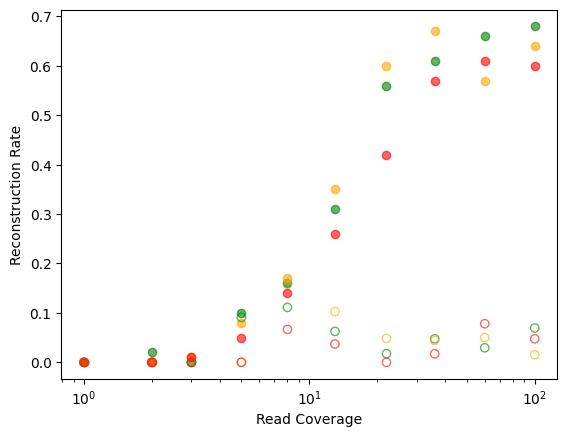

In [211]:
import matplotlib.pyplot as plt

x = coverage_sweep

plt.scatter(x, performance[:, 0,  0],  color = 'Green', alpha = 0.6)
plt.scatter(x, performance[:, 1,  0],  color = 'Orange', alpha = 0.6)
plt.scatter(x, performance[:, 2,  0],  color = 'Red', alpha = 0.6)
plt.ylabel('Reconstruction Rate')

plt.scatter(x, performance[:, 0,  1],  color = 'Green', facecolors='none',  alpha = 0.6)
plt.scatter(x, performance[:, 1,  1],  color = 'Orange', facecolors='none', alpha = 0.6)
plt.scatter(x, performance[:, 2,  1],  color = 'Red', facecolors='none', alpha = 0.6)
plt.xlabel('Read Coverage')
plt.xscale('log')

# plt.scatter(x, 1 - performance[:, 0,  1],  color = 'Forestgreen', alpha = 0.6)
# plt.scatter(x, 1 - performance[:, 1,  1],  color = 'Orangered', alpha = 0.6)
# plt.scatter(x, 1 - performance[:, 2,  1],  color = 'Hotpink', alpha = 0.6)



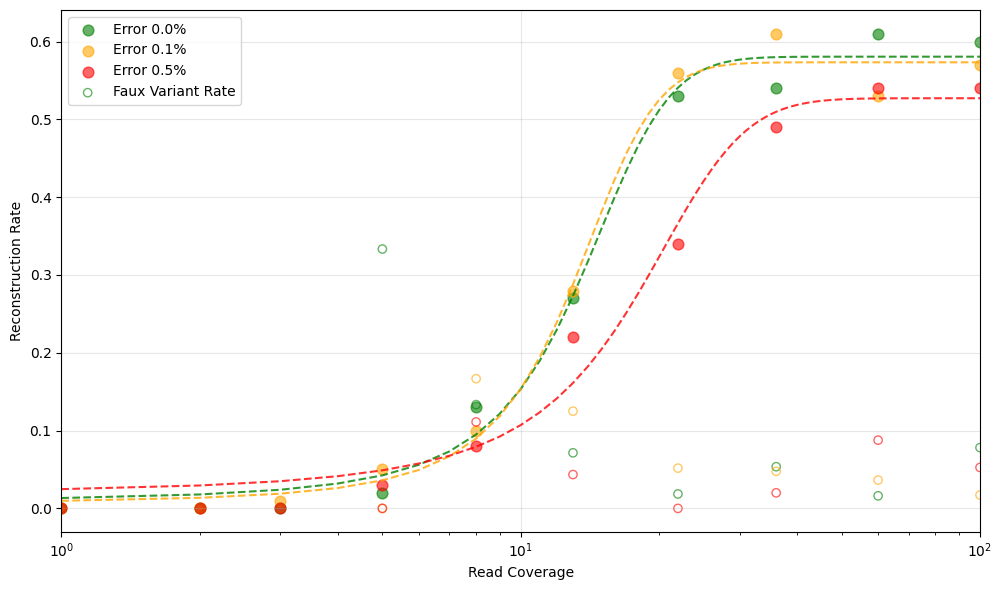

In [199]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def logistic_func(x, L, k, x0):
    """Logistic function for curve fitting"""
    return L / (1 + np.exp(-k * (x - x0)))

x = coverage_sweep

# Colors for different error rates
colors = ['Green', 'Orange', 'Red']
error_labels = ['0.0%', '0.1%', '0.5%']

plt.figure(figsize=(10, 6))

# Plot scatter points and fit curves for reconstruction rates
for i in range(3):
    y_data = performance[:, i, 0]
    
    # Scatter plot
    plt.scatter(x, y_data, color=colors[i], alpha=0.6, label=f'Error {error_labels[i]}', s=60)
    
    # Curve fitting
    try:
        # Initial guess for logistic parameters
        p0 = [max(y_data), 0.1, np.median(x)]
        popt, pcov = curve_fit(logistic_func, x, y_data, p0=p0, maxfev=5000)
        
        # Generate smooth curve
        x_smooth = np.linspace(min(x), max(x), 100)
        y_smooth = logistic_func(x_smooth, *popt)
        
        # Plot fitted curve
        plt.plot(x_smooth, y_smooth, color=colors[i], linestyle='--', alpha=0.8)
    except:
        print(f"Could not fit curve for error rate {error_labels[i]}")

plt.ylabel('Reconstruction Rate')
plt.xlabel('Read Coverage')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.scatter(x, performance[:, 0,  1],  color = 'Green', facecolors='none', alpha = 0.6, label = 'Faux Variant Rate')
plt.scatter(x, performance[:, 1,  1],  color = 'Orange', facecolors='none', alpha = 0.6)
plt.scatter(x, performance[:, 2,  1],  color = 'Red', facecolors='none', alpha = 0.6)
plt.xlabel('Read Coverage')
plt.xlim(1,100)
plt.legend()
plt.show()

[  1.           1.66810054   2.7825594    4.64158883   7.74263683
  12.91549665  21.5443469   35.93813664  59.94842503 100.        ]
[  1   2   3   5   8  13  22  36  60 100]


Next, collect average depth distribution for K00370

In [200]:
import numpy as np

import pandas as pd
from mgsa.helpers import plot

soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'] 
prefixes = ['T0', 'Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'] 



KO = 'K00370'

abundance_dist = []

#collects the relative abundance, given a filepath, sample id, and KO number 
def get_abundance(file_path, sample_id, ko_number):
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if parts[0] == sample_id and parts[1] == ko_number:
                return float(parts[3])
    return 0

#T0 first
file_path = f'../data/KO_table/T0.KO_absolute_average_depth.tsv'
T0samples = pd.read_csv('../data/T0_sampleIDs.tsv', sep = '\t', header = None)
T0samples = T0samples.values
for sample in T0samples:
    abundance_dist.append(get_abundance(file_path, sample, KO))
        
        
#Next, T9

def perturbed_pH_sample(sample):
    metadata = pd.read_csv(f'../data/metadata.tsv', sep='\t')
    metadata = metadata.set_index('sample')
    return metadata.loc[sample, 'pH']

def samples(soil, drug = 'None'):
    sample_IDs = []
    metadata = pd.read_csv('../data/metadata.tsv', sep='\t')
    metadata = metadata.set_index('sample')
    soil_ = soil + '_'
    pHs = []
    for sample in metadata.index:
        if drug in sample and 'T9' in sample and soil_ in sample and 'Nitrate' not in sample:
            sample_IDs.append(sample)
            pHs.append(perturbed_pH_sample(sample))  
    #make sure the samples are organized by increaing perturbed pH
    pHs = np.array(pHs)
    sample_IDs = np.array(sample_IDs)
    indices = np.argsort(pHs)
    sample_IDs = sample_IDs[indices]
    sample_IDs = sample_IDs.tolist()
    return sample_IDs

for soil in soils:
    sample_ids = samples(soil, drug = 'None')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    for sample in sample_ids:
        abundance_dist.append(get_abundance(file_path, sample, KO))
        
for soil in soils:
    sample_ids = samples(soil, drug = 'CHL')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    for sample in sample_ids:
        abundance_dist.append(get_abundance(file_path, sample, KO))
        
print(abundance_dist)


[31.117160509827, 27.1110031229231, 22.9059435973316, 34.4762151616575, 15.7377088378782, 53.3165057176977, 24.8584509845542, 30.2416994542369, 22.4161543719475, 44.0041525664502, 15.9686336376038, 21.5376018754922, 22.3224778808237, 16.6033122801433, 42.7861248655486, 36.170266426732, 25.6024383097625, 21.1033419275364, 30.1802789404427, 25.376413152163, 140.639269256465, 65.9548992654979, 40.2107213085181, 39.7436804215763, 31.2464760645104, 34.6545271376012, 33.948978671453, 25.851503451169, 27.4085397239335, 49.0966306075823, 71.5122600178734, 47.5549348809981, 42.5935805958102, 31.5953422496983, 25.2511223035117, 29.2317315564727, 22.8351321027959, 17.5813741750154, 21.7419869470351, 24.6938463407488, 35.2678573394487, 52.6438548486814, 87.5953352965637, 67.720695290275, 38.3560317765973, 37.3882357985607, 45.6153765479657, 29.7295118648481, 46.3646134897377, 53.6643803086458, 42.588039333882, 54.3803696788482, 94.86220451834, 43.8498138394803, 32.5021843465241, 29.9612532715947, 

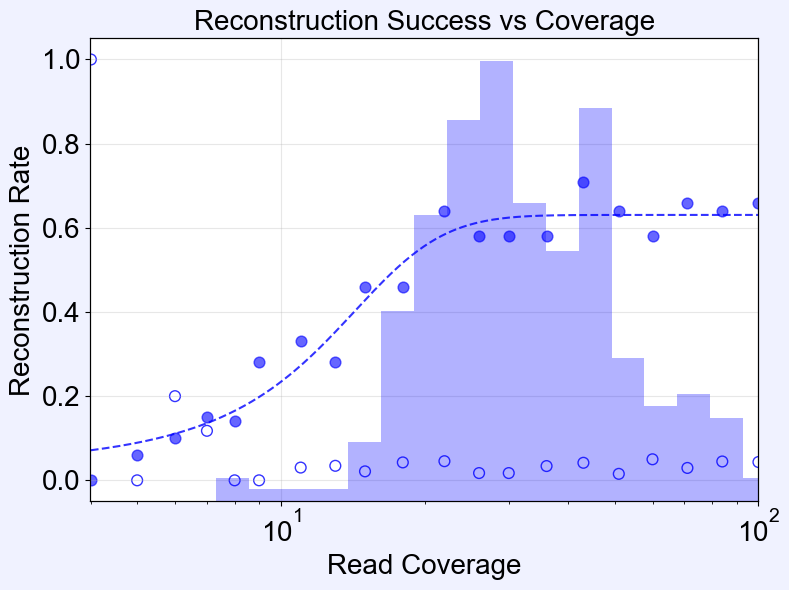

In [268]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def logistic_func(x, L, k, x0):
    """Logistic function for curve fitting"""
    return L / (1 + np.exp(-k * (x - x0)))

x = coverage_sweep

# Colors for different error rates
colors = ['navy', 'darkviolet', 'hotpink']
error_labels = ['0.0%', '0.1%', '0.5%']

# Set font to 10pt Arial
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10

fig, ax1 = plt.subplots(figsize=(8, 6))

fig.patch.set_facecolor('#F0F2FF')

y_data = performance[:, 0, 0]

# Scatter plot
ax1.scatter(x, y_data, color='Blue', alpha=0.6, label='Reconstruction Rate', s=60)

# Curve fitting
try:
    # Initial guess for logistic parameters
    p0 = [max(y_data), 0.1, np.median(x)]
    popt, pcov = curve_fit(logistic_func, x, y_data, p0=p0, maxfev=5000)
    
    # Generate smooth curve
    x_smooth = np.linspace(min(x), max(abundance_dist), 1000)
    y_smooth = logistic_func(x_smooth, *popt)
    
    # Plot fitted curve
    ax1.plot(x_smooth, y_smooth, color='Blue', linestyle='--', alpha=0.8)
except:
    print(f"Could not fit curve for error rate {error_labels[i]}")

# ax1.scatter(x, performance[:, 0,  1],  color = 'Navy', facecolors='none', alpha = 0.6, label = 'Faux Variant Rate')
ax1.scatter(x, performance[:, 0,  1],  color = 'Blue', facecolors='none', alpha = 0.8, label = 'Faux Variant Rate', s=60)
# ax1.scatter(x, performance[:, 2,  1],  color = 'hotpink', facecolors='none', alpha = 0.6)
ax1.set_xlim(1, max(abundance_dist))
ax1.set_ylabel('Reconstruction Rate', fontname='Arial', fontsize=20)
ax1.set_xlabel('Read Coverage', fontname='Arial', fontsize=20)
ax1.set_xscale('log')
ax1.set_xlim(10**0.6, 100)
# ax1.legend(loc='upper left', bbox_to_anchor=(0, 0.9), prop={'family': 'Arial', 'size': 15})
ax1.grid(True, alpha=0.3)

# Create second y-axis for histogram
ax2 = ax1.twinx()
bins = np.logspace(np.log10(min(abundance_dist)), np.log10(max(abundance_dist)), 20)
ax2.hist(abundance_dist, bins=bins, alpha=0.3, color='Blue', label='Abundance Distribution')
# ax2.set_ylabel('Coverage Frequency', fontname='Arial', fontsize=20)

# Add legend for histogram
# ax2.legend(loc='upper left', prop={'family': 'Arial', 'size': 15})
plt.title('Reconstruction Success vs Coverage', fontname='Arial', fontsize=20)

# Set tick labels to Arial as well
ax1.tick_params(axis='both', which='major', labelsize=20)
# ax2.tick_params(axis='both', which='major', labelsize=20)

ax2.set_ylabel('')  # Remove y-axis label
ax2.set_yticklabels([])  # Remove y-axis tick labels
ax2.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)  # Remove ticks

plt.tight_layout()
plt.show()

### Now run the performance assessment for alternative KOs

In [194]:
coverage_sweep = np.rint(np.logspace(0,2,10)).astype(int)
error_sweep = [0.001]

performance = {
    'K00370': np.zeros((len(coverage_sweep), 3)),
    'K00371': np.zeros((len(coverage_sweep), 3)), 
    'K00374': np.zeros((len(coverage_sweep), 3)),
    'K02567': np.zeros((len(coverage_sweep), 3))
}

KO_set = ['K00370', 'K00371', 'K00374', 'K02567']
err = 0.001
for KO in KO_set:
    for i in tqdm.trange(len(coverage_sweep)):
        cov = coverage_sweep[i]
        print('\n')
        print(f"coverage: {cov}, error rate: {err}, KO: {KO}")
        rates, _, _ = assess_reconstruction(
            spikein_faa= f"../out/reconstruction/spikein_{KO}.faa",
            prodigal_faa= f"../out/reconstruction/orfs/{KO}/orfs_{cov:.0f}_{err:.3f}.faa", 
            identity_threshold=0.9, 
            coverage_threshold=0,
            length_threshold = 0.3)  
            
        performance[KO][i, :] = rates
            
        


  0%|          | 0/10 [00:00<?, ?it/s]



coverage: 1, error rate: 0.001, KO: K00370
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 206
Mean spike-in length: 1208 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering: 0

=== Results ===
Successfully reconstructed: 0/100 variants
Reconstruction rate: 0.0%
Full-length ORFs: 0/206
Faux variants: 0/0
Faux variant rate: N/A


coverage: 2, error rate: 0.001, KO: K00370
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 345
Mean spike-in length: 1208 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering: 0

=== Results ===
Successfully reconstructed: 0/100 variants
Reconstruction rate: 0.0%
Full-length ORFs: 0/345
Faux variants: 0/0
Faux variant rate: N/A


coverage: 3, error rate: 0.001, KO: K00370
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 437
Mean spike-in length: 1208 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering:

 30%|███       | 3/10 [00:01<00:03,  1.87it/s]


=== Results ===
Successfully reconstructed: 1/100 variants
Reconstruction rate: 1.0%
Full-length ORFs: 1/437
Faux variants: 0/1
Faux variant rate: 0.0%


coverage: 5, error rate: 0.001, KO: K00370
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 493
Mean spike-in length: 1208 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering: 5


 40%|████      | 4/10 [00:10<00:18,  3.17s/it]

...


=== Results ===
Successfully reconstructed: 77/100 variants
Reconstruction rate: 77.0%
Full-length ORFs: 74/175
Faux variants: 0/74
Faux variant rate: 0.0%


coverage: 60, error rate: 0.001, KO: K02567
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 164
Mean spike-in length: 835 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering: 77


 90%|█████████ | 9/10 [03:55<00:43, 43.23s/it]


=== Results ===
Successfully reconstructed: 77/100 variants
Reconstruction rate: 77.0%
Full-length ORFs: 77/164
Faux variants: 0/77
Faux variant rate: 0.0%


coverage: 100, error rate: 0.001, KO: K02567
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 159
Mean spike-in length: 835 aa
Thresholds: identity ≥ 0.9, coverage ≥ 0
Full-length ORFs after filtering: 80


100%|██████████| 10/10 [05:03<00:00, 30.40s/it]


=== Results ===
Successfully reconstructed: 81/100 variants
Reconstruction rate: 81.0%
Full-length ORFs: 80/159
Faux variants: 0/80
Faux variant rate: 0.0%


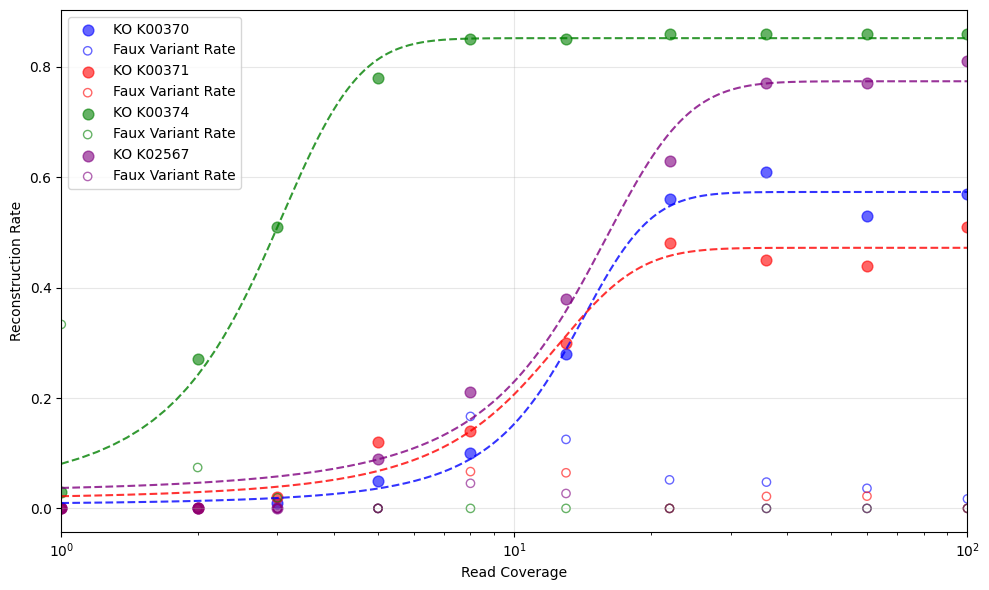

In [195]:


x = coverage_sweep

# Colors for different error rates
colors = ['Blue', 'Red', 'Green', 'Purple']

plt.figure(figsize=(10, 6))

KO_set = ['K00370', 'K00371', 'K00374', 'K02567']
for i, KO in enumerate(KO_set):
    y_data = performance[KO][:, 0]
    
    # Scatter plot
    plt.scatter(x, y_data, color= colors[i], alpha=0.6, label=f'KO {KO_set[i]}', s=60)
    
    # Curve fitting
    try:
        # Initial guess for logistic parameters
        p0 = [max(y_data), 0.1, np.median(x)]
        popt, pcov = curve_fit(logistic_func, x, y_data, p0=p0, maxfev=5000)
        
        # Generate smooth curve
        x_smooth = np.linspace(min(x), max(x), 1000)
        y_smooth = logistic_func(x_smooth, *popt)
        
        # Plot fitted curve
        plt.plot(x_smooth, y_smooth, color=colors[i], linestyle='--', alpha=0.8)
    except:
        print(f"Could not fit curve for error rate {error_labels[i]}")

    plt.ylabel('Reconstruction Rate')
    plt.xlabel('Read Coverage')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.scatter(x, performance[KO][:,  1],  color = colors[i], facecolors='none', alpha = 0.6, label = 'Faux Variant Rate')
    plt.xlabel('Read Coverage')
    plt.xlim(1,100)
    plt.legend()
    
plt.show()

### Do a pairwise comparison of spikeins

=== Pairwise Alignment Analysis ===
Spike-in variants: 100
Computing 100x100 pairwise alignments...


100%|██████████| 100/100 [00:46<00:00,  2.15it/s]


Pairwise identity matrix shape: (100, 100)
Identity range: [0.346, 1.000]


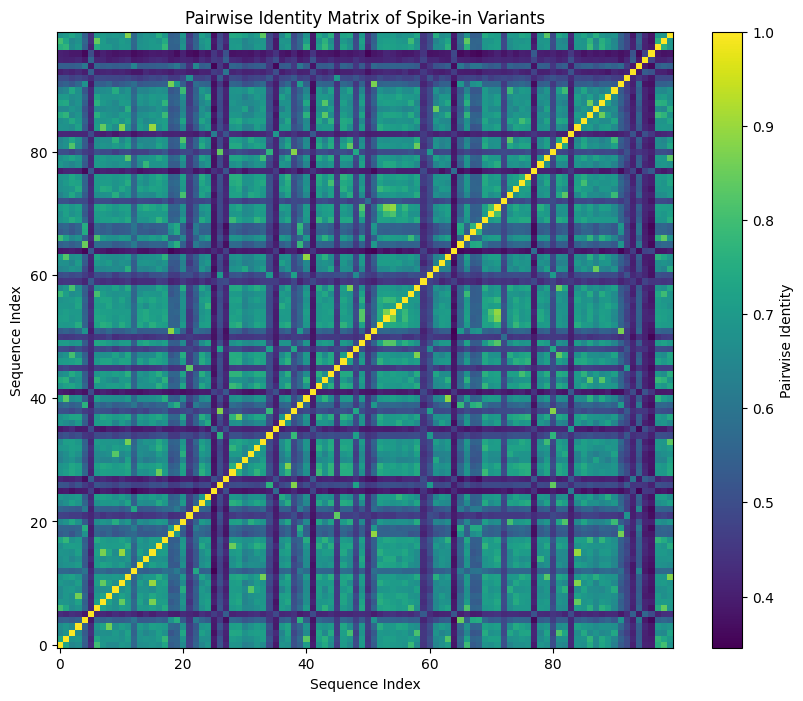

In [208]:
from Bio import SeqIO
from Bio.Align import PairwiseAligner
import numpy as np
import tqdm

KO = 'K02567'

spikein_faa = f'../out/reconstruction/spikein_{KO}.faa'
spikein_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(spikein_faa, "fasta")}


print(f"=== Pairwise Alignment Analysis ===")
print(f"Spike-in variants: {len(spikein_seqs)}")

# Local alignment setup
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.match_score = 1
aligner.mismatch_score = 0
aligner.open_gap_score = -1
aligner.extend_gap_score = 0


n_seqs = len(spikein_seqs)
alignment_matrix = np.zeros((n_seqs, n_seqs))


seq_ids = list(spikein_seqs.keys())
seq_list = list(spikein_seqs.values())

print(f"Computing {n_seqs}x{n_seqs} pairwise alignments...")

for i in tqdm.trange(n_seqs):
    for j in range(i, n_seqs):  
        align = aligner.align(seq_list[i], seq_list[j])[0]
        
        seq1_aligned = align[0]
        seq2_aligned = align[1]
        matches = align.score
        alignment_length = len(seq1_aligned)
        
        gaps = sum(1 for a, b in zip(seq1_aligned, seq2_aligned) if a == '-' or b == '-')
        total_aligned = alignment_length - gaps
        identity = matches / total_aligned if total_aligned > 0 else 0
        
        alignment_matrix[i, j] = identity
        alignment_matrix[j, i] = identity  

print("Pairwise identity matrix shape:", alignment_matrix.shape)
print("Identity range: [{:.3f}, {:.3f}]".format(alignment_matrix.min(), alignment_matrix.max()))

# Optional: Plot the matrix
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(alignment_matrix, cmap='viridis', origin='lower')
plt.colorbar(label='Pairwise Identity')
plt.title('Pairwise Identity Matrix of Spike-in Variants')
plt.xlabel('Sequence Index')
plt.ylabel('Sequence Index')
plt.show()

In [209]:
print(np.mean(alignment_matrix))

0.5748739463715838
